In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path.cwd().parent / "data"
df = pd.read_parquet(DATA_DIR / "matches.parquet")

print(f"Loaded {len(df)} matches across {df['Season'].nunique()} seasons")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
df.head()

Matplotlib is building the font cache; this may take a moment.


Loaded 1512 matches across 5 seasons
Date range: 2021-08-06 to 2026-05-04


,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,BMGMCA,BVCH,BVCD,BVCA,CLCH,CLCD,CLCA,LBCH,LBCD,LBCA
0,P1,2021-08-06,20:15,Sp Lisbon,Vizela,3,0,H,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,P1,2021-08-07,12:45,Arouca,Estoril,0,2,A,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,P1,2021-08-07,18:00,Moreirense,Benfica,1,2,A,1,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,P1,2021-08-07,20:30,Maritimo,Sp Braga,0,2,A,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,P1,2021-08-08,15:30,Guimaraes,Portimonense,0,1,A,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
home_avg = df['FTHG'].mean()
away_avg = df['FTAG'].mean()
print(f"Avg home goals: {home_avg:.3f}")
print(f"Avg away goals: {away_avg:.3f}")
print(f"Total goals/game: {home_avg + away_avg:.3f}")
print(f"Home advantage:  {home_avg - away_avg:.3f}")

results = df['FTR'].value_counts(normalize=True)
print(f"\nHome wins: {results['H']:.1%}")
print(f"Draws:     {results['D']:.1%}")
print(f"Away wins: {results['A']:.1%}")

Avg home goals: 1.466
Avg away goals: 1.185
Total goals/game: 2.651
Home advantage:  0.281

Home wins: 43.3%
Draws:     24.7%
Away wins: 32.1%


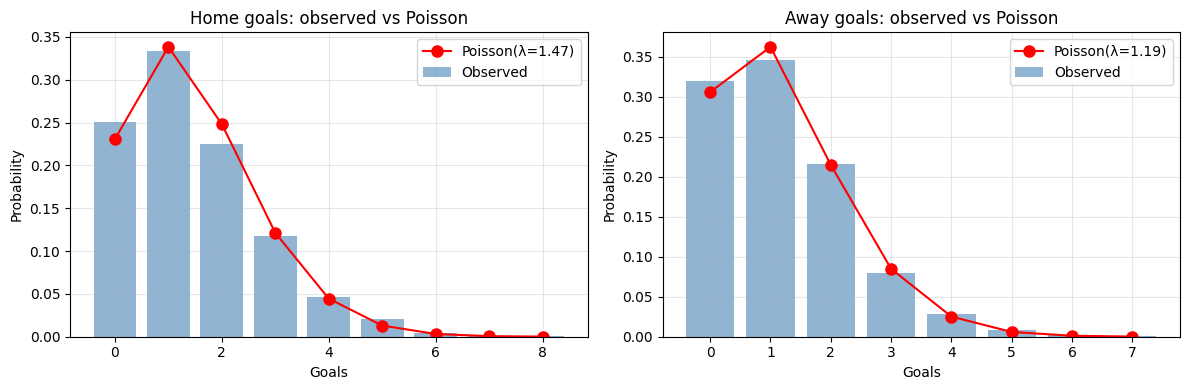

In [3]:
from scipy.stats import poisson

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, label in zip(axes, ['FTHG', 'FTAG'], ['Home', 'Away']):
    observed = df[col].value_counts(normalize=True).sort_index()
    lam = df[col].mean()
    
    ax.bar(observed.index, observed.values, alpha=0.6, label='Observed', color='steelblue')
    
    xs = np.arange(0, max(observed.index) + 1)
    ax.plot(xs, poisson.pmf(xs, lam), 'ro-', label=f'Poisson(λ={lam:.2f})', markersize=8)
    
    ax.set_xlabel('Goals')
    ax.set_ylabel('Probability')
    ax.set_title(f'{label} goals: observed vs Poisson')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()